In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ---------------------------
# Naming convention helpers
# ---------------------------

def parse_slice_name(slice_name: str):
    """
    Expects names like:
      "alpha_mu"  (sweeps alpha vs mu)
      "mu_d"      (sweeps mu vs d)
      "alpha_d"   (sweeps alpha vs d)
    """
    parts = slice_name.split("_")
    if len(parts) != 2:
        raise ValueError(f"slice_name must look like 'alpha_mu' (got {slice_name!r})")
    return parts[0], parts[1]  # (var1, var2)

def choose_axes(var1: str, var2: str):
    """
    Decide x/y labels. I’ll put the second token on x by default
    so 'alpha_mu' -> x=mu, y=alpha matches your current plots.
    """
    xvar, yvar = var2, var1
    return xvar, yvar


In [3]:
def plot_grid_slice(
    base_dir: str,
    slice_name: str,
    held_var: str,
    truth: dict,
    ll_col: str = "loglike",
    contour_deltas=(0.5, 1.0, 2.0, 4.0),
    ll_window: float = 20.0,   # <-- max-ll_window to max
    cmap=None,
):
    var1, var2 = parse_slice_name(slice_name)
    xvar, yvar = choose_axes(var1, var2)

    csv_path = os.path.join(base_dir, f"{slice_name}.csv")
    df = pd.read_csv(csv_path)

    for col in (xvar, yvar, ll_col):
        if col not in df.columns:
            raise ValueError(f"{csv_path} missing column '{col}'. Has: {list(df.columns)}")

    xs = np.sort(df[xvar].unique())
    ys = np.sort(df[yvar].unique())
    XN, YN = len(xs), len(ys)

    LL = np.full((YN, XN), np.nan)
    x_to_j = {x: j for j, x in enumerate(xs)}
    y_to_i = {y: i for i, y in enumerate(ys)}

    for _, row in df.iterrows():
        i = y_to_i[row[yvar]]
        j = x_to_j[row[xvar]]
        LL[i, j] = row[ll_col]

    held_text = ""
    if held_var is not None and held_var in truth:
        held_text = f" ({held_var} fixed = {truth[held_var]:g})"
    elif held_var is not None:
        held_text = f" ({held_var} fixed)"

    # ---------------------------
    # Plot: raw loglike heatmap (rescaled) + contours
    # ---------------------------
    plt.figure(figsize=(6, 5))

    LLmax = np.nanmax(LL)
    vmin = LLmax - ll_window
    vmax = LLmax

    im = plt.imshow(
        LL,
        origin="lower",
        aspect="auto",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar(im, label=ll_col)
    plt.xlabel(xvar)
    plt.ylabel(yvar)
    plt.title(f"2D {ll_col}: {yvar}–{xvar} (shown [{vmin:.1f}, {vmax:.1f}]){held_text}")

    # Contours at max - delta
    deltas = np.array(contour_deltas, dtype=float)
    levels = np.sort(LLmax - deltas)

    plt.contour(
        xs, ys, LL,
        levels=levels,
        colors="white",
        linewidths=1.2,
    )

    if (xvar in truth) and (yvar in truth):
        plt.scatter(truth[xvar], truth[yvar], color="red", marker="x", s=80, label="ground truth")
        plt.legend()

    plt.tight_layout()
    plt.show()

    return xs, ys, LL, csv_path

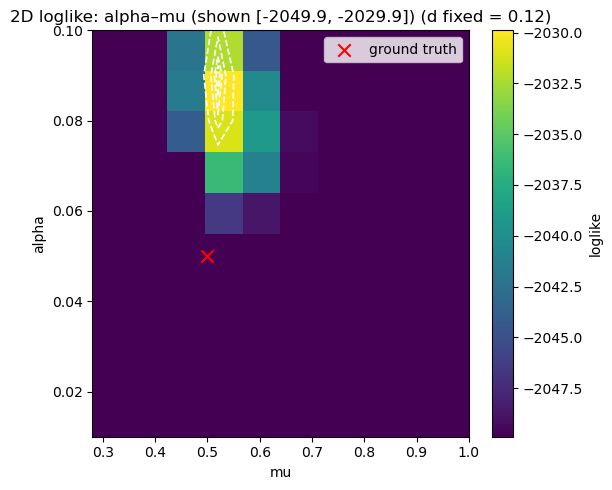

(array([0.28, 0.36, 0.44, 0.52, 0.6 , 0.68, 0.76, 0.84, 0.92, 1.  ]),
 array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([[-5312.88967235, -2826.00787173, -2445.31568901, -2395.74229345,
         -2384.92845738, -2383.38141587, -2381.35423001, -2383.18089104,
         -2381.91283886, -2379.76908336],
        [-4748.26287835, -2591.79156179, -2259.92302852, -2226.95010189,
         -2216.40251501, -2214.56401375, -2213.44758808, -2215.30685153,
         -2214.99668788, -2218.12852619],
        [-4034.54840899, -2444.47434654, -2171.82314525, -2139.47677304,
         -2135.96320835, -2136.88258804, -2137.10493711, -2139.49790707,
         -2141.91753828, -2142.3891538 ],
        [-4170.44369111, -2413.95864978, -2117.78668162, -2091.72640606,
         -2089.90154651, -2093.24518778, -2096.36217822, -2100.02653097,
         -2101.86808614, -2104.77725827],
        [-4433.46738067, -2327.44852345, -2092.68642933, -2063.16236222,
         -2064.47674444, -2067.4943

In [4]:
ALPHA_TRUE = 0.05
MU_TRUE    = 0.5
D_TRUE     = 0.12

truth = {"alpha": ALPHA_TRUE, "mu": MU_TRUE, "d": D_TRUE}

# alpha–mu slice with d fixed
plot_grid_slice(
    base_dir="recovery_tests/grid",
    slice_name="alpha_mu",
    held_var="d",
    truth=truth,
)

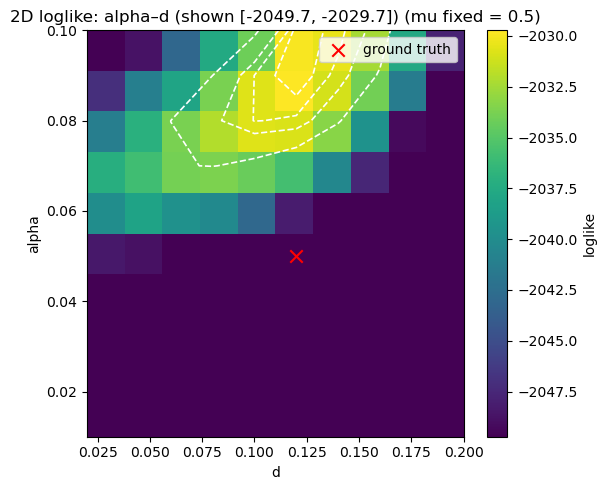

(array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ]),
 array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([[-2343.69298294, -2358.76793983, -2363.17726314, -2370.6063922 ,
         -2386.12280563, -2410.95110766, -2425.77760341, -2446.63723162,
         -2473.97160337, -2509.16317071],
        [-2178.57593025, -2186.47776477, -2196.99951186, -2205.11948036,
         -2217.87356157, -2230.0559955 , -2243.70515352, -2264.61391614,
         -2285.93817561, -2323.78078906],
        [-2105.06653638, -2111.30871312, -2118.98492146, -2125.79907996,
         -2133.6394557 , -2146.38351658, -2159.20237791, -2178.34506594,
         -2198.64883047, -2232.45780917],
        [-2068.37939515, -2070.27058934, -2074.81077632, -2081.3437177 ,
         -2087.61114501, -2095.53548028, -2105.10498757, -2120.09960459,
         -2139.53785366, -2168.38523226],
        [-2048.41535573, -2048.85188369, -2052.29789814, -2053.9218568 ,
         -2058.93944258, -2066.1689

In [5]:
plot_grid_slice(
    base_dir="recovery_tests/grid",
    slice_name="alpha_d",
    held_var="mu",
    truth=truth,
)

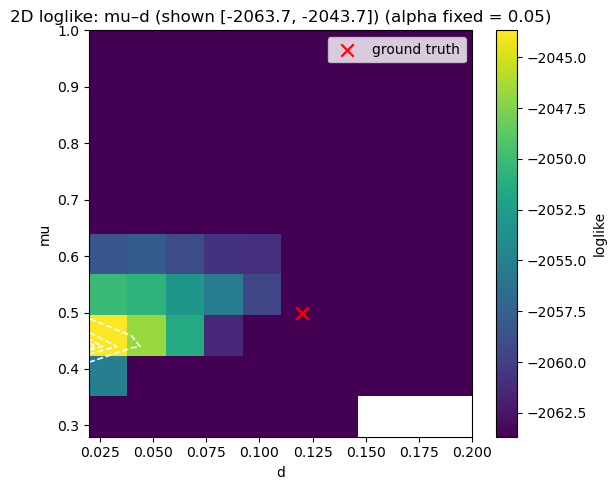

(array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ]),
 array([0.28, 0.36, 0.44, 0.52, 0.6 , 0.68, 0.76, 0.84, 0.92, 1.  ]),
 array([[-2224.92970074, -2502.28089244, -2723.58037803, -3135.4310153 ,
         -3689.95189179, -4343.11116985, -4942.03034756,           -inf,
                   -inf,           -inf],
        [-2055.05568618, -2073.87340089, -2100.10760567, -2134.85487077,
         -2274.79336216, -2334.40432878, -2663.05149129, -2893.11139286,
         -3257.20492364, -3787.11078959],
        [-2043.67681623, -2046.74855274, -2051.43740777, -2061.35581624,
         -2071.55607914, -2085.59849159, -2116.25757258, -2131.9184271 ,
         -2203.04502905, -2307.46166531],
        [-2050.12948398, -2050.72098797, -2053.12697947, -2055.18477718,
         -2059.44787116, -2063.78783235, -2068.25396948, -2079.06676607,
         -2090.08410861, -2105.27081899],
        [-2058.42136952, -2057.87476256, -2059.06900669, -2060.75867495,
         -2060.99473166, -2064.4122

In [6]:
plot_grid_slice(
    base_dir="recovery_tests/grid",
    slice_name="mu_d",
    held_var="alpha",
    truth=truth,
)